# 01 — Data Preparation

## Goal
Parse tBLASTn results for MROH6 in the zebra finch genome using **two protein
queries** (XP_030133788.3 and XP_072787743.1) combined with **exon 13 BLASTn
anchors** to define biologically meaningful gene units, filter for quality,
classify by chromosomal origin, and produce a multiple sequence alignment for
downstream evolutionary analysis.

## Scientific context

**MROH6** (Maestro Heat-Like Repeat Family Member 6) encodes a protein
containing HEAT-like repeats — alpha-helical solenoid structures that mediate
protein-protein interactions (Andrade & Bork, 1995, *Nature Genetics*
11:115–116). In most vertebrate genomes, MROH6 exists as a **single-copy gene**
adjacent to the lanosterol synthase gene (LSS) on a single chromosome.

In the zebra finch (*Taeniopygia guttata*; Warren et al., 2010, *Nature*
464:757–762), a tBLASTn search (by Dr. Monaco) of the MROH6 protein against the
genome assembly (bTaeGut1.4.pri; Rhie et al., 2021, *Nature* 592:737–746)
returned thousands of hits — an extraordinary amplification from a single-copy
gene. This raises a fundamental question: **what duplication mechanism generated
thousands of MROH6 copies?**

### Two protein queries and the intron 3 difference

Two alternate MROH6 transcripts produce proteins that differ in the inclusion or
exclusion of **intron 3** in the mRNA:
- **XP_030133788.3** — isoform X2 (643 aa), excludes intron 3
- **XP_072787743.1** — isoform X1 (646 aa, annotated as MROH7), includes intron 3

Using both queries ensures we capture gene copies that match only one transcript
structure. File 1 (XP_030133788.3) yields 3,039 hits; File 2 (XP_072787743.1)
yields 3,059 hits; combined and deduplicated = 3,471 unique hits.

### Exon 13 anchor strategy

A 44 bp conserved probe from **exon 13** (BLASTn search) identifies 411 gene
unit positions across the genome. This probe is present in almost all copies
except **chr Z** and **chr 20**, where gene units are defined from tBLASTn hits
alone. This anchor-based approach yields **~419 gene units** — a more
biologically accurate count than the fragment-merge heuristic.

### Two competing hypotheses

| Feature | DNA-mediated duplication | RNA-mediated duplication (retrotransposition) |
|---|---|---|
| **Mechanism** | Unequal crossing-over or segmental duplication during DNA replication | mRNA → cDNA via reverse transcriptase → genomic insertion |
| **Error rate** | ~10⁻⁹–10⁻¹⁰ per base/replication (Kunkel, 2004, *J Biol Chem* 279:16895) | ~10⁻⁴–10⁻⁵ per base/cycle (Preston, 1996, *Science* 275:228) |
| **Expected distribution** | Tandem clusters near parental locus | Dispersed across chromosomes (random insertion) |
| **Expected divergence** | Low (~0.01–0.05 subs/site; Lynch & Conery, 2000, *Science* 290:1151) | Elevated (RT errors + neutral drift) |
| **Ts/Tv ratio** | ~0.5 (random expectation) | >1.0 (RT transition bias; Wakeley, 1996, *J Mol Evol* 42:681) |

## Strategy
Gene units are defined by exon 13 anchors. Each anchor position marks one gene
copy. tBLASTn hits from both protein queries are assigned to the nearest anchor.
Chromosomes lacking exon 13 anchors (chr Z, chr 20) have gene units defined by
merging overlapping tBLASTn hits.

**Inputs:**
- `Zebra finch input files/Taeniopygia guttata tBLASTn MROH6 XP_030133788.3 alignment.txt`
- `Zebra finch input files/Taeniopygia guttata tBLASTn MROH6 XP_072787743.1 alignment.txt`
- `Zebra finch input files/MROH6 exon 13 V5SBW1G0014-Alignment.txt`

**Outputs:** `data/processed/mroh6_gene_units.fasta`,
`data/processed/mroh6_aligned.fasta`, `data/processed/mroh6_gene_units_table.csv`

In [1]:
import sys
sys.path.insert(0, '../scripts')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO, AlignIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from pathlib import Path
import subprocess

from utils import (
    parse_blast_fasta, parse_exon13_blastn, parse_combined_tblastn,
    build_accession_to_chrom, define_gene_units, gene_units_to_fasta,
    merge_overlapping_hits, loci_to_fasta
)

DATA_RAW = Path('../data/raw')
DATA_PROC = Path('../data/processed')
RESULTS = Path('../results')
INPUT_DIR = Path('../Zebra finch input files')

sns.set_context('notebook')
sns.set_style('whitegrid')

## 1a. Parse exon 13 anchors and combined tBLASTn hits

**Exon 13 anchor:** A 44 bp conserved probe from exon 13 was searched with
BLASTn against the zebra finch genome. Each hit marks the position of one MROH6
gene unit. This probe is found in almost all copies except chr Z and chr 20.

**Two tBLASTn queries:** Two alternate MROH6 protein isoforms (XP_030133788.3
and XP_072787743.1) differ in the inclusion/exclusion of intron 3. Using both
queries captures gene copies that may only match one transcript structure.
The two result files are combined and deduplicated by exact genomic coordinates.

In [2]:
# --- Parse exon 13 BLASTn anchors ---
exon13_file = INPUT_DIR / 'MROH6 exon 13 V5SBW1G0014-Alignment.txt'
exon13 = parse_exon13_blastn(exon13_file)
print(f"Exon 13 anchors: {len(exon13)} hits across {exon13['saccver'].nunique()} accessions")
print(f"\nAnchors per accession (top 10):")
print(exon13['saccver'].value_counts().head(10))

# --- Parse and combine both tBLASTn files ---
tblastn_file1 = INPUT_DIR / 'Taeniopygia guttata tBLASTn MROH6 XP_030133788.3 alignment.txt'
tblastn_file2 = INPUT_DIR / 'Taeniopygia guttata tBLASTn MROH6 XP_072787743.1 alignment.txt'

df1 = parse_blast_fasta(tblastn_file1)
df2 = parse_blast_fasta(tblastn_file2)
tblastn = parse_combined_tblastn(tblastn_file1, tblastn_file2)

print(f"\ntBLASTn hits:")
print(f"  XP_030133788.3 (isoform X2): {len(df1)}")
print(f"  XP_072787743.1 (isoform X1): {len(df2)}")
print(f"  Combined (deduplicated):     {len(tblastn)}")
print(f"  New hits from 2nd query:     {len(tblastn) - len(df1)}")

# Build accession -> chromosome mapping
acc_to_chrom = build_accession_to_chrom(tblastn)

# Check which accessions lack exon 13 coverage
exon13_accs = set(exon13['saccver'].unique())
blast_accs = set(tblastn['accession'].unique())
missing_accs = blast_accs - exon13_accs
print(f"\nAccessions in tBLASTn but missing exon 13 anchor:")
for acc in sorted(missing_accs):
    chrom = acc_to_chrom.get(acc, '?')
    n_hits = len(tblastn[tblastn['accession'] == acc])
    print(f"  {acc} (chr {chrom}): {n_hits} tBLASTn hits")

Exon 13 anchors: 411 hits across 21 accessions

Anchors per accession (top 10):
saccver
NC_133041.1    85
NC_133050.1    52
NC_133060.1    48
NC_133055.1    36
NC_133054.1    35
NC_133056.1    31
NC_133058.1    24
NC_133059.1    24
NC_133062.1    22
NC_133061.1    13
Name: count, dtype: int64

tBLASTn hits:
  XP_030133788.3 (isoform X2): 3039
  XP_072787743.1 (isoform X1): 3059
  Combined (deduplicated):     3471
  New hits from 2nd query:     432

Accessions in tBLASTn but missing exon 13 anchor:
  NC_133045.1 (chr 20): 2 tBLASTn hits
  NC_133063.1 (chr Z): 24 tBLASTn hits


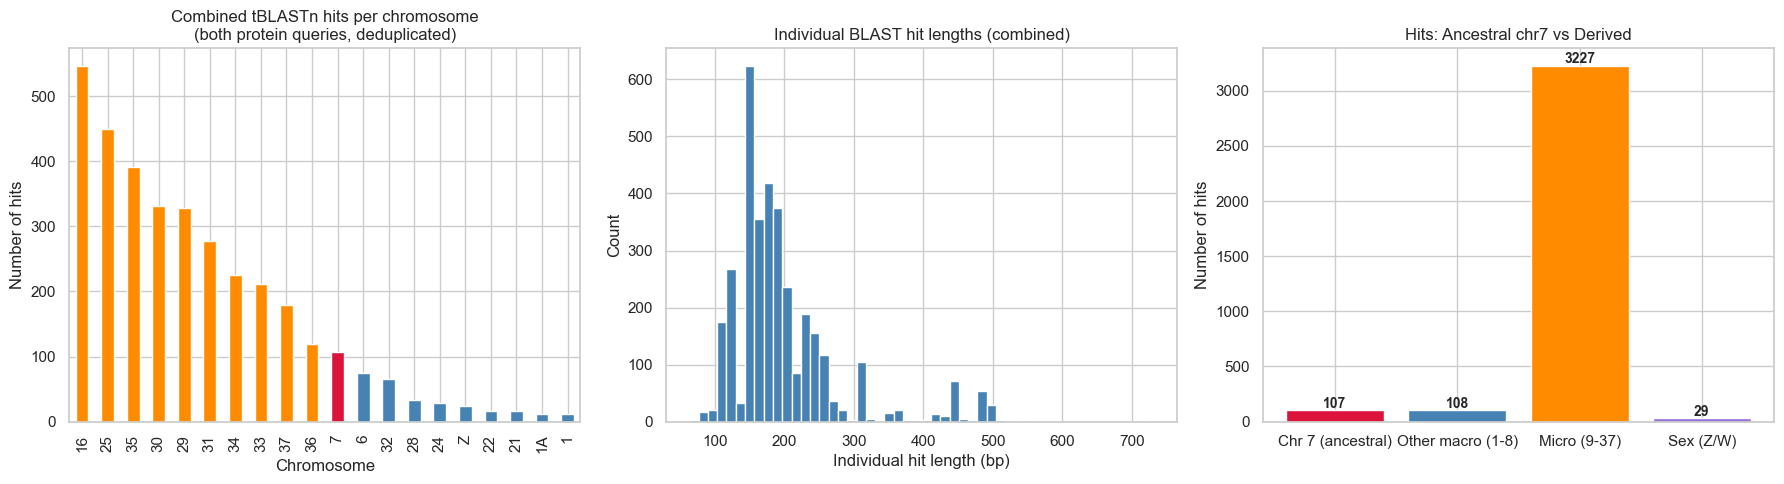

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Combined chromosome distribution
chrom_counts = tblastn['chrom'].value_counts().head(20)
colors = ['crimson' if c == '7' else ('darkorange' if c in ['16','25','29','30','31','33','34','35','36','37'] else 'steelblue')
          for c in chrom_counts.index]
chrom_counts.plot.bar(ax=axes[0], color=colors)
axes[0].set_title('Combined tBLASTn hits per chromosome\n(both protein queries, deduplicated)')
axes[0].set_xlabel('Chromosome')
axes[0].set_ylabel('Number of hits')

# Sequence length distribution
axes[1].hist(tblastn['seq_len'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Individual BLAST hit lengths (combined)')
axes[1].set_xlabel('Individual hit length (bp)')
axes[1].set_ylabel('Count')

# Macro vs Micro chromosome breakdown
macro_chroms = ['1', '1A', '2', '3', '4', '4A', '5', '6', '7', '8']
micro_chroms = [c for c in tblastn['chrom'].unique() if c not in macro_chroms and c not in ['Z', 'W', 'unknown']]
cats = {'Chr 7 (ancestral)': len(tblastn[tblastn['chrom'] == '7']),
        'Other macro (1-8)': len(tblastn[(tblastn['chrom'].isin(macro_chroms)) & (tblastn['chrom'] != '7')]),
        'Micro (9-37)': len(tblastn[tblastn['chrom'].isin(micro_chroms)]),
        'Sex (Z/W)': len(tblastn[tblastn['chrom'].isin(['Z', 'W'])])}
axes[2].bar(cats.keys(), cats.values(), color=['crimson', 'steelblue', 'darkorange', 'mediumpurple'])
axes[2].set_title('Hits: Ancestral chr7 vs Derived')
axes[2].set_ylabel('Number of hits')
for i, (k, v) in enumerate(cats.items()):
    axes[2].text(i, v + 20, str(v), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS / 'figures' / 'blast_hit_overview.png', dpi=150, bbox_inches='tight')
plt.show()

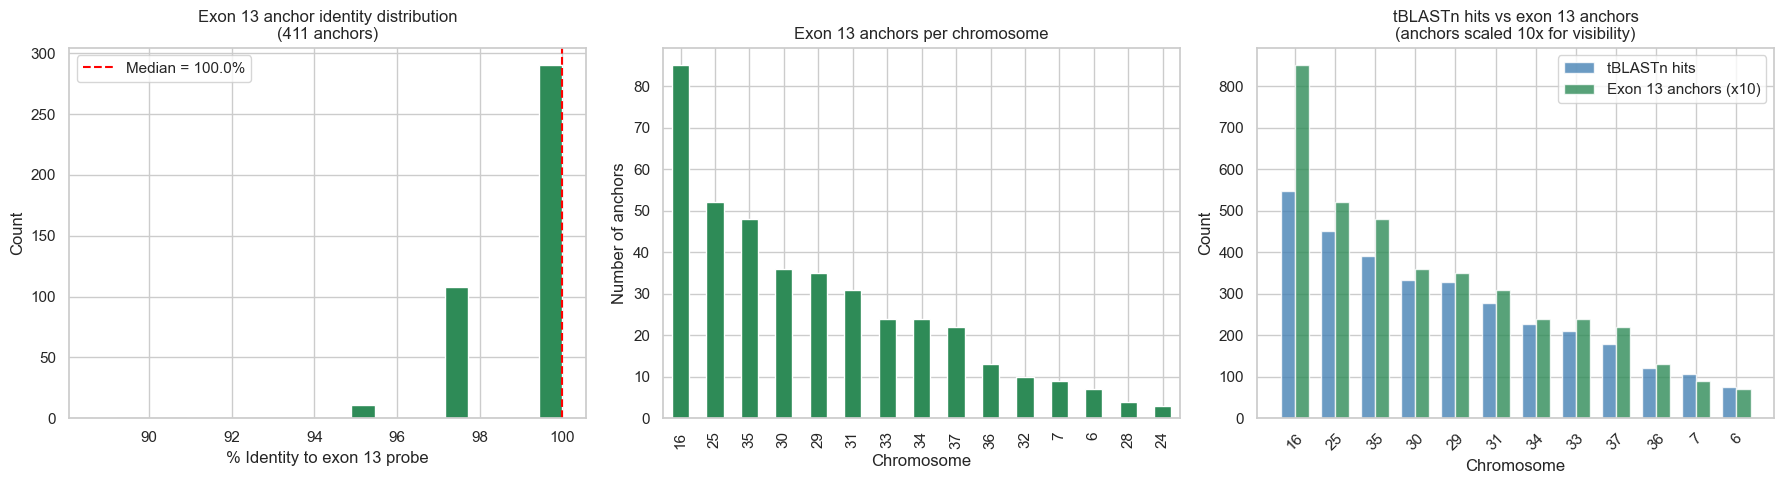

In [4]:
# Exon 13 anchor quality: identity distribution and spacing
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Exon 13 identity distribution
ax = axes[0]
ax.hist(exon13['pident'], bins=20, color='seagreen', edgecolor='white')
ax.set_xlabel('% Identity to exon 13 probe')
ax.set_ylabel('Count')
ax.set_title(f'Exon 13 anchor identity distribution\n({len(exon13)} anchors)')
ax.axvline(exon13['pident'].median(), color='red', linestyle='--',
           label=f'Median = {exon13["pident"].median():.1f}%')
ax.legend()

# Exon 13 anchors per chromosome (mapped to chrom names)
ax = axes[1]
exon13_chroms = exon13['saccver'].map(acc_to_chrom).fillna('unknown')
chrom_counts_e13 = exon13_chroms.value_counts().head(15)
chrom_counts_e13.plot.bar(ax=ax, color='seagreen')
ax.set_title('Exon 13 anchors per chromosome')
ax.set_xlabel('Chromosome')
ax.set_ylabel('Number of anchors')

# Compare: exon 13 anchors vs tBLASTn hits per chromosome
ax = axes[2]
blast_by_chrom = tblastn['chrom'].value_counts()
e13_by_chrom = exon13_chroms.value_counts()
compare_chroms = blast_by_chrom.head(12).index
x = range(len(compare_chroms))
w = 0.35
ax.bar([i - w/2 for i in x], [blast_by_chrom.get(c, 0) for c in compare_chroms],
       w, label='tBLASTn hits', color='steelblue', alpha=0.8)
ax.bar([i + w/2 for i in x], [e13_by_chrom.get(c, 0) * 10 for c in compare_chroms],
       w, label='Exon 13 anchors (x10)', color='seagreen', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(compare_chroms, rotation=45)
ax.set_xlabel('Chromosome')
ax.set_ylabel('Count')
ax.set_title('tBLASTn hits vs exon 13 anchors\n(anchors scaled 10x for visibility)')
ax.legend()

plt.tight_layout()
plt.savefig(RESULTS / 'figures' / 'exon13_anchor_quality.png', dpi=150, bbox_inches='tight')
plt.show()

## 1b. Define gene units using exon 13 anchors

**Why exon 13 anchors?** The previous approach merged overlapping tBLASTn hits
using a 500 bp gap heuristic, producing 812 loci that were then filtered to 596.
This approach has two problems: (1) it can over-merge distinct gene copies that
happen to be close together, and (2) it can under-count gene copies when hits
are sparse.

The exon 13 anchor approach is biologically grounded: each exon 13 BLASTn hit
marks the precise position of one MROH6 gene copy. tBLASTn hits from both
protein queries are then assigned to the nearest anchor within 25 kb.

For chr Z and chr 20 (which lack exon 13 anchors), gene units are defined by
merging overlapping tBLASTn hits with a 500 bp gap tolerance.

### Processing steps:
1. Each exon 13 BLASTn hit = 1 gene unit anchor (411 anchors)
2. Assign combined tBLASTn hits to nearest anchor (within 25 kb)
3. Add gene units from non-anchored chromosomes (chr Z, chr 20) via merge
4. Classify by chromosome type
5. Apply length filter for downstream analysis

In [5]:
# Define gene units using exon 13 anchors + combined tBLASTn
gu = define_gene_units(exon13, tblastn, acc_to_chrom, max_dist=25000, merge_gap=500)

print(f"Total gene units defined: {len(gu)}")
print(f"  With exon 13 anchor:     {gu['has_exon13'].sum()}")
print(f"  Without anchor (chr Z/20): {(~gu['has_exon13']).sum()}")
print(f"  With tBLASTn coverage:   {(gu['n_hits'] > 0).sum()}")
print(f"\nGene units per chromosome:")
print(gu['chrom'].value_counts().head(15))
print(f"\nSequence length stats (all gene units with hits):")
with_seq = gu[gu['total_seq_len'] > 0]
print(with_seq['total_seq_len'].describe())

Total gene units defined: 419
  With exon 13 anchor:     411
  Without anchor (chr Z/20): 8
  With tBLASTn coverage:   419

Gene units per chromosome:
chrom
16    85
25    52
35    48
30    36
29    35
31    31
34    24
33    24
37    22
36    13
32    10
7      9
Z      7
6      7
28     4
Name: count, dtype: int64

Sequence length stats (all gene units with hits):
count     419.000000
mean     1440.019093
std       370.684334
min        96.000000
25%      1296.000000
50%      1497.000000
75%      1623.000000
max      3360.000000
Name: total_seq_len, dtype: float64


In [6]:
# Classify chromosomes and identify ancestral copy
MACRO_CHROMS = {'1', '1A', '2', '3', '4', '4A', '5', '6', '7', '8'}
SEX_CHROMS = {'Z', 'W'}

def classify_chrom(chrom):
    if chrom == '7':
        return 'chr7_ancestral'
    elif chrom in MACRO_CHROMS:
        return 'macro_derived'
    elif chrom in SEX_CHROMS:
        return 'sex_chrom'
    else:
        return 'micro_derived'

gu['chrom_class'] = gu['chrom'].apply(classify_chrom)

# Identify ancestral copy: largest gene unit on chr7 near 28.8 Mb (LSS region)
chr7_gu = gu[(gu['chrom'] == '7') & (gu['start'] > 28_000_000) & (gu['end'] < 29_500_000)]
if len(chr7_gu) > 0:
    ancestral_idx = chr7_gu['total_seq_len'].idxmax()
    ancestral_gu_id = gu.loc[ancestral_idx, 'gene_unit_id']
    gu['is_ancestral'] = gu['gene_unit_id'] == ancestral_gu_id
    print(f"Ancestral copy: gu_{ancestral_gu_id} (chr7, span={gu.loc[ancestral_idx, 'span']}bp, "
          f"seq={gu.loc[ancestral_idx, 'total_seq_len']}bp)")
else:
    gu['is_ancestral'] = False
    print("WARNING: Could not identify ancestral locus near chr7:28.8Mb")

print(f"\nChromosome classification:")
print(gu['chrom_class'].value_counts())

# Apply length filter
MIN_LENGTH = 300
gu_filtered = gu[gu['total_seq_len'] >= MIN_LENGTH].copy()
print(f"\nLength filter (>= {MIN_LENGTH} bp):")
print(f"  Before: {len(gu)} gene units")
print(f"  After:  {len(gu_filtered)} gene units")
print(f"  Removed: {len(gu) - len(gu_filtered)} short/empty gene units")
print(f"\nFiltered chromosome classification:")
print(gu_filtered['chrom_class'].value_counts())

Ancestral copy: gu_17 (chr7, span=4748bp, seq=2733bp)

Chromosome classification:
chrom_class
micro_derived     391
macro_derived      11
chr7_ancestral      9
sex_chrom           8
Name: count, dtype: int64

Length filter (>= 300 bp):
  Before: 419 gene units
  After:  411 gene units
  Removed: 8 short/empty gene units

Filtered chromosome classification:
chrom_class
micro_derived     387
macro_derived      10
chr7_ancestral      8
sex_chrom           6
Name: count, dtype: int64


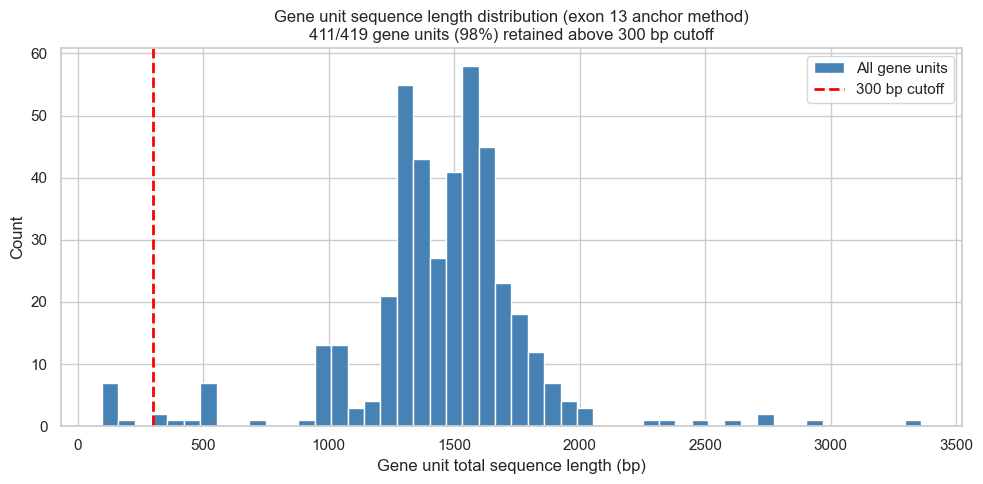

In [7]:
# Gene unit length distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(gu['total_seq_len'], bins=50, color='steelblue', edgecolor='white', label='All gene units')
ax.axvline(MIN_LENGTH, color='red', linestyle='--', linewidth=2, label=f'{MIN_LENGTH} bp cutoff')

n_kept = len(gu_filtered)
n_total = len(gu)
pct_kept = 100 * n_kept / n_total

ax.set_title(f'Gene unit sequence length distribution (exon 13 anchor method)\n'
             f'{n_kept}/{n_total} gene units ({pct_kept:.0f}%) retained above {MIN_LENGTH} bp cutoff')
ax.set_xlabel('Gene unit total sequence length (bp)')
ax.set_ylabel('Count')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(RESULTS / 'figures' / 'merged_locus_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

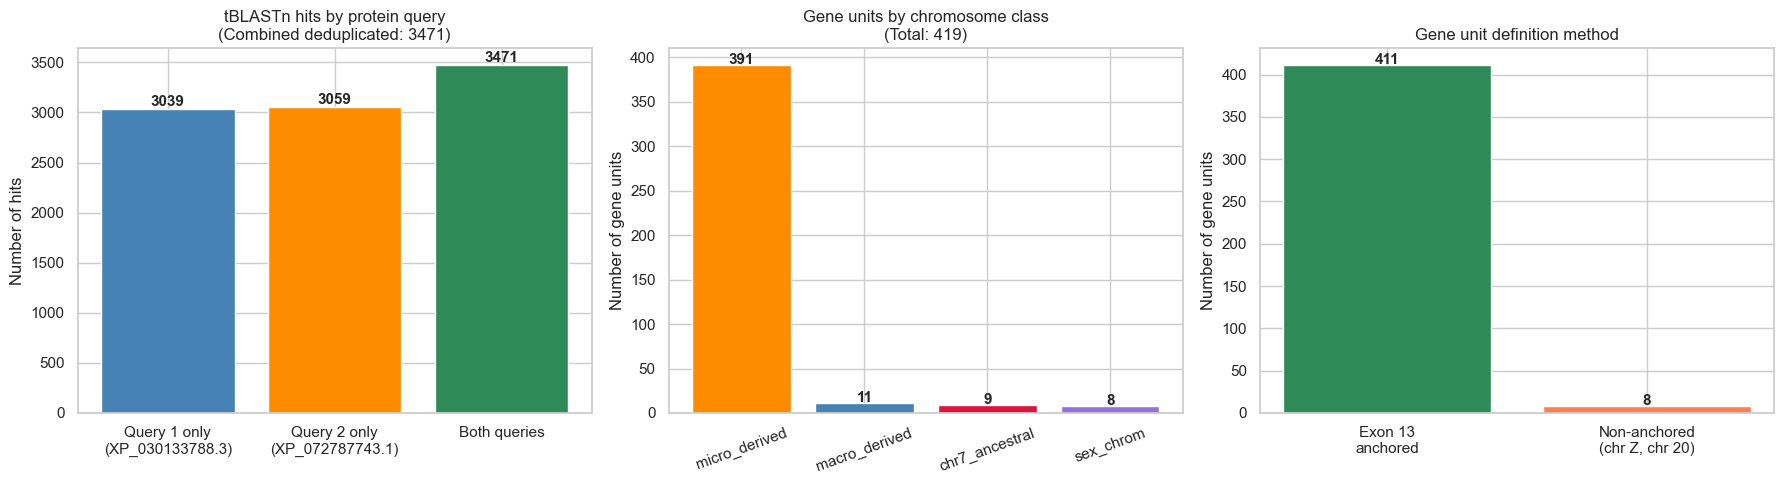

In [8]:
# Additional insight: What did the 2nd tBLASTn query add?
# Compare hits unique to each query vs shared
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Venn-style bar: shared vs unique hits
shared_mask = tblastn['source'].str.contains('030133788')
unique_to_q1 = len(df1) - len(tblastn[shared_mask])  # approximate
n_shared = len(tblastn[tblastn.duplicated(subset=['accession', 'start', 'end', 'strand'], keep=False)])
ax = axes[0]
bars = ax.bar(['Query 1 only\n(XP_030133788.3)', 'Query 2 only\n(XP_072787743.1)', 'Both queries'],
              [len(df1), len(df2), len(tblastn)],
              color=['steelblue', 'darkorange', 'seagreen'])
ax.set_ylabel('Number of hits')
ax.set_title(f'tBLASTn hits by protein query\n(Combined deduplicated: {len(tblastn)})')
for bar, val in zip(bars, [len(df1), len(df2), len(tblastn)]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, str(val),
            ha='center', fontsize=11, fontweight='bold')

# Gene units by chromosome class
ax = axes[1]
class_counts = gu['chrom_class'].value_counts()
colors_map = {'micro_derived': 'darkorange', 'chr7_ancestral': 'crimson',
              'macro_derived': 'steelblue', 'sex_chrom': 'mediumpurple'}
ax.bar(class_counts.index, class_counts.values,
       color=[colors_map.get(c, 'gray') for c in class_counts.index])
ax.set_title(f'Gene units by chromosome class\n(Total: {len(gu)})')
ax.set_ylabel('Number of gene units')
for i, (cls, cnt) in enumerate(class_counts.items()):
    ax.text(i, cnt + 1, str(cnt), ha='center', fontsize=11, fontweight='bold')
ax.tick_params(axis='x', rotation=20)

# Exon 13 anchored vs non-anchored gene units
ax = axes[2]
anchored = gu[gu['has_exon13']]
non_anchored = gu[~gu['has_exon13']]
ax.bar(['Exon 13\nanchored', 'Non-anchored\n(chr Z, chr 20)'],
       [len(anchored), len(non_anchored)],
       color=['seagreen', 'coral'])
ax.set_title('Gene unit definition method')
ax.set_ylabel('Number of gene units')
for i, v in enumerate([len(anchored), len(non_anchored)]):
    ax.text(i, v + 1, str(v), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS / 'figures' / 'gene_unit_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Write filtered gene units to FASTA
output_fasta = DATA_PROC / 'mroh6_gene_units.fasta'
n_written = gene_units_to_fasta(gu_filtered, output_fasta)
print(f"Wrote {n_written} gene units to {output_fasta.name}")

# Save gene unit metadata table
gu_filtered.drop(columns=['sequence']).to_csv(
    DATA_PROC / 'mroh6_gene_units_table.csv', index=False
)
print("Saved gene unit metadata to mroh6_gene_units_table.csv")

# Also write the old-format files for backwards compatibility with notebook 02
loci_table_path = DATA_PROC / 'mroh6_loci_table.csv'
compat_df = gu_filtered.rename(columns={'gene_unit_id': 'locus_id'})
compat_df.drop(columns=['sequence'], errors='ignore').to_csv(loci_table_path, index=False)
loci_to_fasta(compat_df, DATA_PROC / 'mroh6_copies_filtered.fasta')

# Show breakdown
print(f"\n--- Chr 7 (parent) vs Derived chromosomes ---")
chr7_out = gu_filtered[gu_filtered['chrom'] == '7']
derived_out = gu_filtered[gu_filtered['chrom'] != '7']
print(f"  Chr 7 gene units:   {len(chr7_out)} ({chr7_out['total_seq_len'].sum():,} bp total)")
print(f"  Derived gene units: {len(derived_out)} ({derived_out['total_seq_len'].sum():,} bp total)")
print(f"  Expansion ratio:    {len(derived_out)/max(len(chr7_out),1):.1f}x more copies on derived chromosomes")

Wrote 411 gene units to mroh6_gene_units.fasta
Saved gene unit metadata to mroh6_gene_units_table.csv

--- Chr 7 (parent) vs Derived chromosomes ---
  Chr 7 gene units:   8 (15,123 bp total)
  Derived gene units: 403 (587,288 bp total)
  Expansion ratio:    50.4x more copies on derived chromosomes


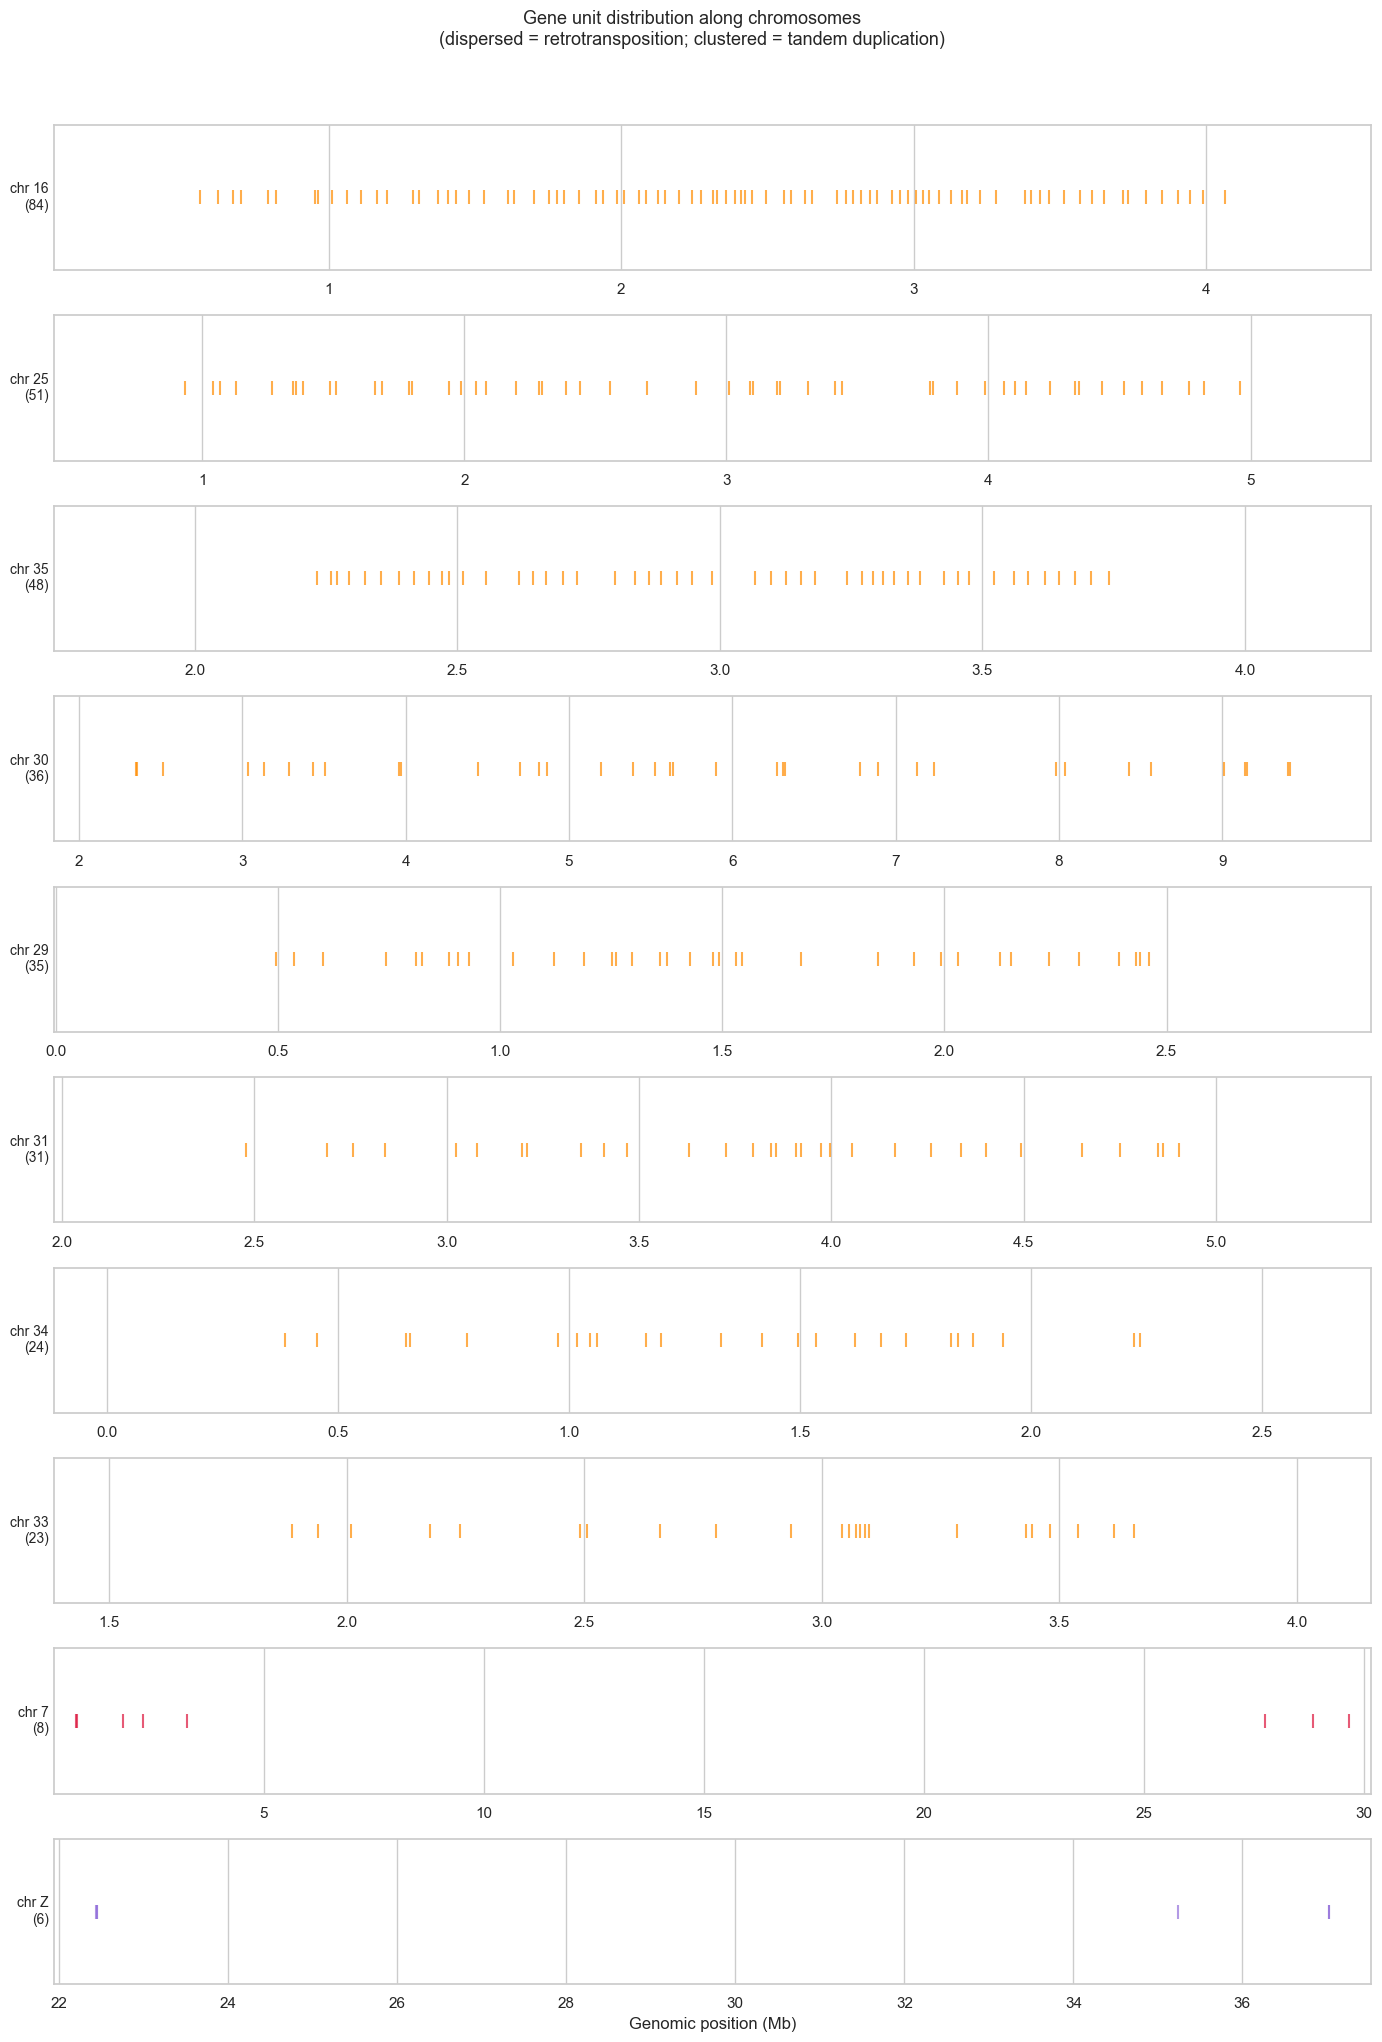

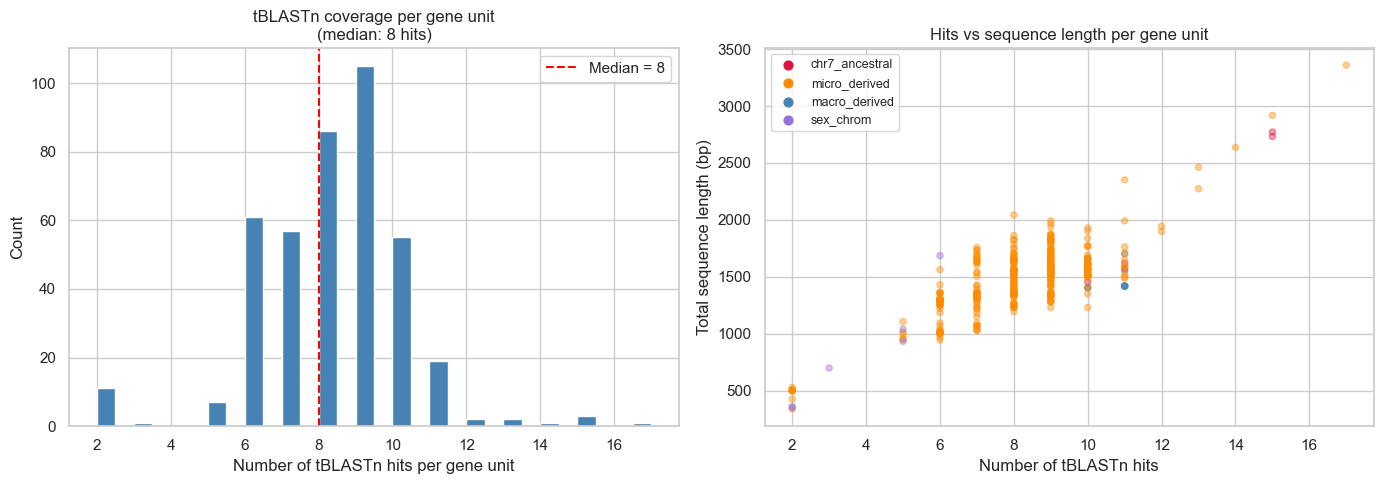

In [10]:
# Genomic distribution: gene unit positions along each chromosome
# This visualizes whether copies are dispersed (retrotransposition) or clustered (tandem duplication)
top_chroms = gu_filtered['chrom'].value_counts().head(8).index.tolist()
if '7' not in top_chroms:
    top_chroms.append('7')
if 'Z' not in top_chroms and 'Z' in gu_filtered['chrom'].values:
    top_chroms.append('Z')

fig, axes = plt.subplots(len(top_chroms), 1, figsize=(14, 2 * len(top_chroms)), sharex=False)
if len(top_chroms) == 1:
    axes = [axes]

for ax, chrom in zip(axes, top_chroms):
    chrom_gu = gu_filtered[gu_filtered['chrom'] == chrom]
    positions = chrom_gu['start'].values / 1e6  # Convert to Mb
    color = 'crimson' if chrom == '7' else ('mediumpurple' if chrom == 'Z' else 'darkorange')
    ax.scatter(positions, [1]*len(positions), marker='|', s=100, color=color, alpha=0.7)
    ax.set_yticks([])
    ax.set_ylabel(f'chr {chrom}\n({len(chrom_gu)})', rotation=0, ha='right', va='center', fontsize=10)
    ax.set_xlim(positions.min() - 0.5, positions.max() + 0.5)

axes[-1].set_xlabel('Genomic position (Mb)')
fig.suptitle('Gene unit distribution along chromosomes\n(dispersed = retrotransposition; clustered = tandem duplication)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS / 'figures' / 'gene_unit_genomic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Hits-per-gene-unit distribution — shows how much tBLASTn coverage each gene unit has
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(gu_filtered['n_hits'], bins=30, color='steelblue', edgecolor='white')
ax.set_xlabel('Number of tBLASTn hits per gene unit')
ax.set_ylabel('Count')
ax.set_title(f'tBLASTn coverage per gene unit\n(median: {gu_filtered["n_hits"].median():.0f} hits)')
ax.axvline(gu_filtered['n_hits'].median(), color='red', linestyle='--', label=f'Median = {gu_filtered["n_hits"].median():.0f}')
ax.legend()

ax = axes[1]
ax.scatter(gu_filtered['n_hits'], gu_filtered['total_seq_len'], alpha=0.4, s=20,
           c=gu_filtered['chrom_class'].map({'chr7_ancestral': 'crimson', 'macro_derived': 'steelblue',
                                              'micro_derived': 'darkorange', 'sex_chrom': 'mediumpurple'}))
ax.set_xlabel('Number of tBLASTn hits')
ax.set_ylabel('Total sequence length (bp)')
ax.set_title('Hits vs sequence length per gene unit')
# Add legend
for cls, color in [('chr7_ancestral', 'crimson'), ('micro_derived', 'darkorange'),
                    ('macro_derived', 'steelblue'), ('sex_chrom', 'mediumpurple')]:
    ax.scatter([], [], c=color, label=cls, s=40)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS / 'figures' / 'gene_unit_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

## 1c. Align with MAFFT

Multiple sequence alignment across all filtered gene units using MAFFT
(Katoh & Standley, 2013, *Mol Biol Evol* 30:772-780). `--auto` selects the
optimal strategy based on dataset size. Gap-rich columns (>50% gaps) are
trimmed to retain only informative alignment positions.

In [11]:
# Run MAFFT alignment on filtered gene units
input_fasta = DATA_PROC / 'mroh6_gene_units.fasta'
output_fasta = DATA_PROC / 'mroh6_aligned.fasta'

result = subprocess.run(
    ['mafft', '--auto', '--thread', '-1', str(input_fasta)],
    capture_output=True, text=True
)

if result.returncode == 0:
    with open(output_fasta, 'w') as f:
        f.write(result.stdout)
    print(f"MAFFT alignment complete: {output_fasta}")
else:
    print(f"MAFFT error:\n{result.stderr}")

MAFFT alignment complete: ../data/processed/mroh6_aligned.fasta


In [12]:
# QC: Alignment statistics
alignment = AlignIO.read(output_fasta, 'fasta')
n_seqs = len(alignment)
aln_len = alignment.get_alignment_length()
print(f"Alignment: {n_seqs} sequences x {aln_len} columns")

# Calculate gap fraction per column
gap_fracs = []
for col_idx in range(aln_len):
    col = alignment[:, col_idx]
    gap_fracs.append(col.count('-') / n_seqs)
gap_fracs = np.array(gap_fracs)

print(f"Columns with >50% gaps: {(gap_fracs > 0.5).sum()} / {aln_len}")
print(f"Columns with 0% gaps: {(gap_fracs == 0).sum()} / {aln_len}")

Alignment: 411 sequences x 9738 columns
Columns with >50% gaps: 8479 / 9738
Columns with 0% gaps: 0 / 9738


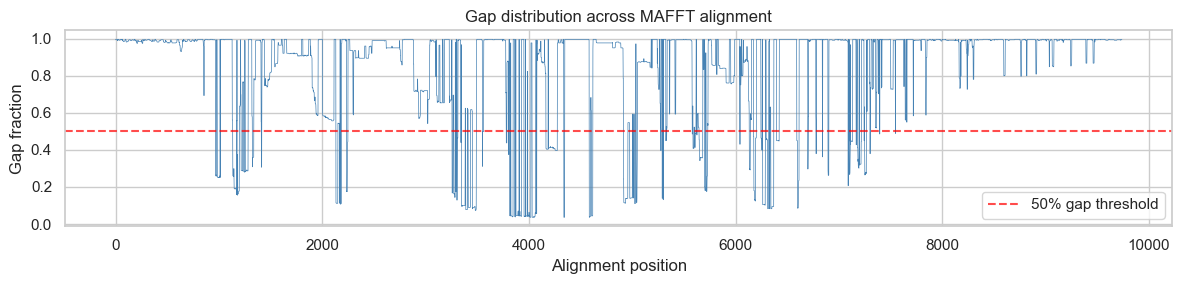

In [13]:
# Visualize gap distribution
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(gap_fracs, color='steelblue', linewidth=0.5)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.7, label='50% gap threshold')
ax.set_xlabel('Alignment position')
ax.set_ylabel('Gap fraction')
ax.set_title('Gap distribution across MAFFT alignment')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / 'figures' / 'alignment_gap_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Remove columns with >50% gaps and save trimmed alignment
keep_cols = np.where(gap_fracs <= 0.5)[0]
trimmed_records = []
for record in alignment:
    trimmed_seq = ''.join(str(record.seq)[i] for i in keep_cols)
    trimmed_records.append(SeqRecord(Seq(trimmed_seq), id=record.id, description=''))

trimmed_path = DATA_PROC / 'mroh6_aligned_trimmed.fasta'
SeqIO.write(trimmed_records, trimmed_path, 'fasta')
print(f"Trimmed alignment: {len(trimmed_records)} sequences x {len(keep_cols)} columns")
print(f"Saved to {trimmed_path}")

Trimmed alignment: 411 sequences x 1259 columns
Saved to ../data/processed/mroh6_aligned_trimmed.fasta


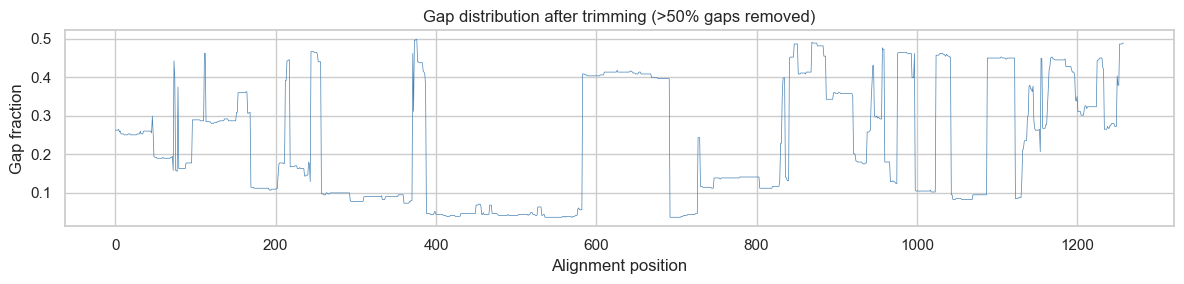

In [15]:
# Visualize gap distribution after trimming
trimmed_alignment = AlignIO.read(trimmed_path, 'fasta')
n_seqs_trimmed = len(trimmed_alignment)
aln_len_trimmed = trimmed_alignment.get_alignment_length()
gap_fracs_trimmed = []
for col_idx in range(aln_len_trimmed):
    col = trimmed_alignment[:, col_idx]
    gap_fracs_trimmed.append(col.count('-') / n_seqs_trimmed)
gap_fracs_trimmed = np.array(gap_fracs_trimmed)

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(gap_fracs_trimmed, color='steelblue', linewidth=0.5)
ax.set_xlabel('Alignment position')
ax.set_ylabel('Gap fraction')
ax.set_title('Gap distribution after trimming (>50% gaps removed)')
plt.tight_layout()
plt.savefig(RESULTS / 'figures' / 'alignment_gap_distribution_trimmed.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Summary
print("=" * 60)
print("DATA PREPARATION SUMMARY")
print("=" * 60)
print(f"Exon 13 anchors:         {len(exon13)}")
print(f"tBLASTn hits (file 1):   {len(df1)} (XP_030133788.3)")
print(f"tBLASTn hits (file 2):   {len(df2)} (XP_072787743.1)")
print(f"Combined (deduplicated): {len(tblastn)}")
print(f"  New hits from query 2: {len(tblastn) - len(df1)}")
print(f"Gene units defined:      {len(gu)}")
print(f"  With exon 13 anchor:   {gu['has_exon13'].sum()}")
print(f"  Without anchor:        {(~gu['has_exon13']).sum()} (chr Z, chr 20)")
print(f"Length filter:           >= {MIN_LENGTH} bp")
print(f"Filtered gene units:     {len(gu_filtered)}")
print(f"  Chr 7 (ancestral):     {len(gu_filtered[gu_filtered['chrom']=='7'])}")
print(f"  Macro-derived:         {len(gu_filtered[gu_filtered['chrom_class']=='macro_derived'])}")
print(f"  Micro-derived:         {len(gu_filtered[gu_filtered['chrom_class']=='micro_derived'])}")
print(f"  Sex chromosomes:       {len(gu_filtered[gu_filtered['chrom_class']=='sex_chrom'])}")
if 'is_ancestral' in gu.columns:
    anc = gu[gu['is_ancestral']]
    if len(anc) > 0:
        print(f"Ancestral copy:          gu_{anc.iloc[0]['gene_unit_id']} (chr7, {anc.iloc[0]['span']}bp span)")
print(f"\nAlignment: {len(trimmed_records)} sequences x {len(keep_cols)} columns (trimmed)")
print(f"\n=> Proceed to Step 02 with {len(gu_filtered)} filtered gene units")

DATA PREPARATION SUMMARY
Exon 13 anchors:         411
tBLASTn hits (file 1):   3039 (XP_030133788.3)
tBLASTn hits (file 2):   3059 (XP_072787743.1)
Combined (deduplicated): 3471
  New hits from query 2: 432
Gene units defined:      419
  With exon 13 anchor:   411
  Without anchor:        8 (chr Z, chr 20)
Length filter:           >= 300 bp
Filtered gene units:     411
  Chr 7 (ancestral):     8
  Macro-derived:         10
  Micro-derived:         387
  Sex chromosomes:       6
Ancestral copy:          gu_17 (chr7, 4748bp span)

Alignment: 411 sequences x 1259 columns (trimmed)

=> Proceed to Step 02 with 411 filtered gene units
